<a href="https://colab.research.google.com/github/IagoAlmeida-ias/Programa-o-em-int-arti-generativa/blob/main/opecv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Imagem original com marcação---


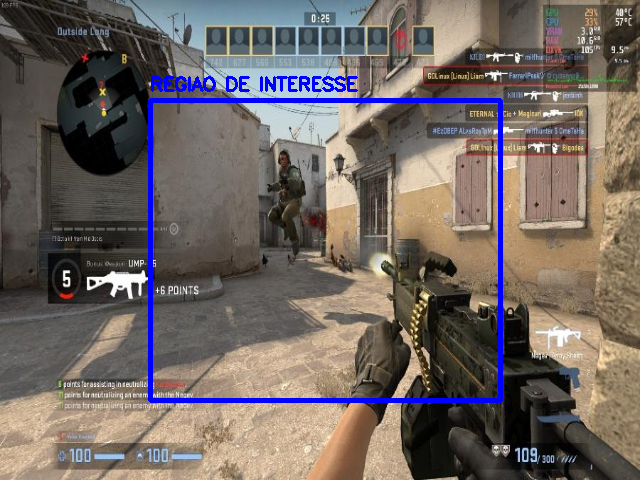


--- Imagem em escala de cinza---


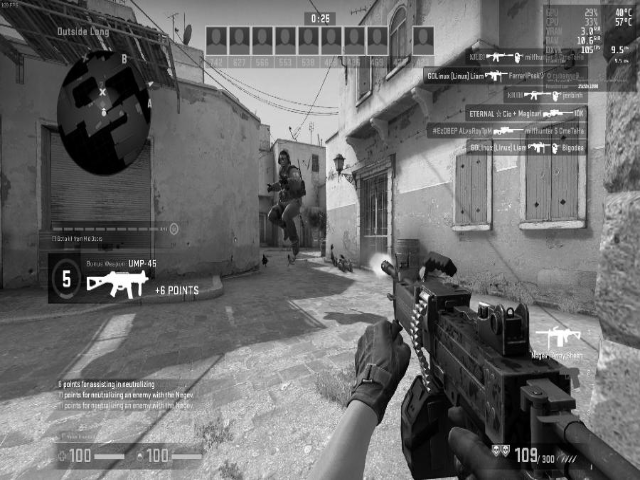

In [1]:
# LEITURA E MODIFICAÇÃO DE IMAGEM ESTÁTICA
import cv2
from google.colab.patches import cv2_imshow # Exclusivo para renderizar imagens no Google Colab

# 1. Carregar a imagem
imagem = cv2.imread('cenario.jpg')

# 2. Redimensionar para um tamanho padrão de exibição
imagem = cv2.resize(imagem, (640, 480))

# 3. converte para escala de cinza (simplificação matemática da matriz)
imagem_cinza = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

# Desenhar uma caixa de marcação manual em uma área da imagem
# Parâmetros: cv2.rectangle(imagem, 9x_inicio, y_inicio), (x_fim, y_fim), (B, G, R), espessura)
cv2.rectangle(imagem,(150, 100), (500, 400), (255, 0, 0), 3)
cv2.putText(imagem, "REGIAO DE INTERESSE", (150, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

# 4. Exibir os resultados na tela
print("--- Imagem original com marcação---")
cv2_imshow(imagem)

print("\n--- Imagem em escala de cinza---")
cv2_imshow(imagem_cinza)

In [2]:
!pip install easyocr opencv-python

[SISTEMA] Escaneando caracteres da placa...

[SUCESSO] Texto extraído pela IA: POX4G21

--- Recorte focado enviado para a IA ---


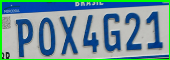


--- Resultado do Sistema de Monitoramento ---


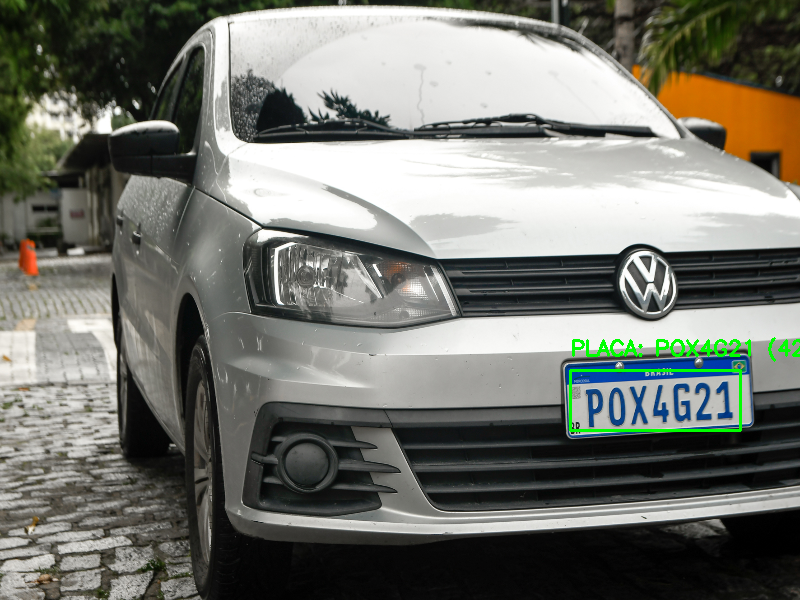

In [20]:
# LEITURA AUTOMAÇÃO DE PLACAS
import cv2
import easyocr
from google.colab.patches import cv2_imshow

# 1. Inicializar o leitor de OCR da IA para o idioma Português
leitor_ocr = easyocr.Reader(['pt'])

# 2. Carregar a imagem do veículo e redimensionar para maner m padrão
imagem_veiculo = cv2.imread('carro.jpg')
imagem_veiculo = cv2.resize(imagem_veiculo, (800, 600))

# 3. Converte para escala de cinza para facilitar a leitura de caracteres pela IA
imagem_cinza = cv2.cvtColor(imagem_veiculo, cv2.COLOR_BGR2GRAY)

# Coordenadas

x_ini, x_fim = 570, 740
y_ini, y_fim = 370, 430

placa_recortada_cinza = imagem_cinza[y_ini:y_fim, x_ini:x_fim]
placa_recortada_colorida = imagem_veiculo[y_ini:y_fim, x_ini:x_fim]

# 4. Passar o recorte na Ia de OCR para extrair as letras/números
print("[SISTEMA] Escaneando caracteres da placa..." )
resultados_ocr = leitor_ocr.readtext(placa_recortada_cinza)

#5. Extrair o texto encontrado se a IA conseguir ler algo
if len(resultados_ocr) > 0:
    # O resultado do EasyOCR vem no formato: [ (coordenadas) , "TEXTO DETECTADO", score_confiança]
    texto_placa = resultados_ocr[0][1].upper().replace(" ","")
    confianca = resultados_ocr[0][2] * 100

    # Usar o OpenCV para desenhar o resultado de volta na imagem do carrro
    cv2.rectangle(imagem_veiculo, (x_ini, y_ini), (x_fim, y_fim), (0, 255, 0), 2)
    cv2.putText(imagem_veiculo, f"PLACA: {texto_placa} ({confianca:.1f}%)",
               (x_ini, y_ini -15), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    print(f"\n[SUCESSO] Texto extraído pela IA: {texto_placa}")
else:
    print("\n[ALERTA] A IA não conseguiu decifrar os caracteres. Ajuste o recorte da ROI.")
    texto_placa = "NÃO DETECTADA"

# 6. Exibir o painel sivual final para validação
print("\n--- Recorte focado enviado para a IA ---")
cv2_imshow(placa_recortada_colorida)

print("\n--- Resultado do Sistema de Monitoramento ---")
cv2_imshow(imagem_veiculo)